In [ ]:
import torch
import sys
import numpy as np
from scipy.optimize import minimize
import os
import tqdm as tqdm
from sklearn.metrics import accuracy_score

sys.path.append('../../rss/')

# datasets
from datasets.halfmnist import HALFMNIST
from datasets.addmnist import ADDMNIST
from datasets.shortcutmnist import SHORTMNIST

# models
from models.mnistltn import MnistLTN
from models.mnistdpl import MnistDPL
from argparse import Namespace

args = Namespace(
    backbone="conceptizer",
    preprocess=0,
    finetuning=0,
    batch_size=128,
    n_epochs=100,
    validate=1,
    dataset="shortmnist",
    lr=0.001,
    exp_decay=0.99,
    warmup_steps=0,
    wandb=None,
    task="addition",
    boia_model="ce",
    model="mnistdpl",
    c_sup=0,
    which_c=[-1],
    joint=False,
    boia_ood_knowledge=True,
    seed=0
 )

## Utilities

In [24]:
def get_single_concept_gold_priors(hidden_labels, num_classes):
    """
    Computes the exact marginal distribution (r) from the hidden gold labels.
    
    Args:
        hidden_labels: A list or numpy array of all ground truth concept in your dataset.
        num_classes: The total number of unique classes (c).
        
    Returns:
        priors: A numpy array of shape (c,) summing to 1.
    """
    # count occ. of each class
    print(f"Distinct hidden labels: {np.unique(hidden_labels)}")
    counts = np.bincount(hidden_labels, minlength=num_classes)
    
    # normalize for probabilities
    priors = counts / np.sum(counts)
    
    return priors

def get_concept_joint_gold_priors(hidden_label_pairs, num_classes):
    """
    Computes the exact joint distribution (r) from the hidden gold label pairs.
    
    Args:
        hidden_label_pairs: A list or numpy array of all ground truth concept pairs in your dataset.
        num_classes: The total number of unique classes (c).
        
    Returns:
        priors: A numpy array of shape (c, c) summing to 1.
    """
    # count occ. of each class pair
    counts = np.zeros((num_classes, num_classes))
    for pair in hidden_label_pairs:
        counts[pair[0], pair[1]] += 1
    
    # normalize for probabilities
    priors = counts / np.sum(counts)
    
    return priors

def get_sigma_matrix(num_classes, priors, symbolic_function):
    """
    Constructs the sigma matrix (Σ_σ,r) described in Equation (1) which depends on the class priors.
    """
    dim = num_classes ** 2
    Sigma = np.zeros((dim, dim))
    
    # iterate over all possible gold label pairs (i, j)
    for i in range(num_classes):
        for j in range(num_classes):
            # probabilty of this gold label pair occurring (assuming independence) i.e. P(Y=i) * P(Y=j)
            prob_gold = priors[i] * priors[j]
            
            # the correct weak label for this gold label pair
            s_true = symbolic_function(i, j)
            
            for i_prime in range(num_classes):
                for j_prime in range(num_classes):
                    s_pred = symbolic_function(i_prime, j_prime) # s' = σ(i', j')
                    
                    # if weak labels differ, this contributes to the Partial Risk
                    if s_true != s_pred:
                        # u corresponds to confusion H[i, i_prime]
                        # v corresponds to confusion H[j, j_prime]
                        u = i * num_classes + i_prime
                        v = j * num_classes + j_prime
                        
                        Sigma[u, v] += prob_gold        
    return Sigma

def compute_class_specific_risk_bound(
    target_class_index,
    observed_partial_risk,
    num_classes,
    Sigma
):
    """
    Solves optimization program (2) to find the worst-case risk bound R_j(f).
    """
    dim = num_classes ** 2
    
    # Objective: Maximize risk R_j(f)
    # since scipy only does minimization, we minimize the 'Probability Correct' instead i.e.
    # Risk = 1 - Probability Correct
    def objective(h):
        # the diagonal entry H[j, j] corresponds to P(Pred=j | Gold=j)
        # in the flattended vector h, this is at index (j * num_classes + j)
        correct_pred_idx = target_class_index * num_classes + target_class_index
        prob_correct = h[correct_pred_idx]
        
        return prob_correct

    # Constraint 1: Partial Risk Match (Eq 2, first constraint)
    # h^T * Sigma * h = R_P    # Constraint 1: Partial Risk Match (Eq 2, first constraint)
    # h^T * Sigma * h = R_P
    def constraint_partial_risk(h):
        return (h.T @ Sigma ) @ h - observed_partial_risk
    
    # Constraint 2: Normalization (Eq 2, third constraint)
    # Each row of H must sum to 1
    constraints = [{'type': 'eq', 'fun': constraint_partial_risk}]
    
    for r in range(num_classes):
        def row_sum_constraint(h, row_idx=r):
            start = row_idx * num_classes
            end = start + num_classes
            return np.sum(h[start:end]) - 1.0
        constraints.append({'type': 'eq', 'fun': row_sum_constraint})

    # Bounds: Probabilities must be between 0 and 1 (Eq 2, second constraint)
    bounds = [(0, 1) for _ in range(dim)]
    
    # Initial guess: Identity matrix
    h0 = np.eye(num_classes).flatten()
    
    # Optimization
    result = minimize(
        objective, 
        h0, 
        method='SLSQP', 
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 1000, 'ftol': 1e-6}
    )
    
    if not result.success:
        print(f"Warning: Optimization failed for class {target_class_index}")
        return None
        
    # Convert minimized Prob_Correct back to Risk
    return 1.0 - result.fun
 
def get_concepts_and_labels_mnist(
    out_labels, out_concepts, true_concepts, dataset_name, is_ood=False
):
    label_logits = out_labels
    
    if not is_ood and dataset_name.lower() in ["shortmnist", "clipshortmnist", "shortmnist"]:
        label_logits = label_logits.clone()
        allowed = torch.tensor([6, 10, 12], device=label_logits.device)
        disallowed = torch.ones(label_logits.size(1), dtype=torch.bool, device=label_logits.device)
        disallowed[allowed] = False
        label_logits[:, disallowed] = 0

    predicted_labels = torch.argmax(label_logits, dim=-1)
    predicted_concepts = torch.argmax(out_concepts, dim=-1)

    predicted_concepts = predicted_concepts.reshape(-1) # from [batch_size, 2] to [batch_size * 2]
    refactored_true_concepts = true_concepts.reshape(-1) # from [batch_size, 2] to [batch_size * 2]

    return predicted_labels, predicted_concepts, refactored_true_concepts 

def get_dataset(datasetname, args):
    name = datasetname.lower()
    
    if name == "shortmnist":
        return SHORTMNIST(args)
    if name == 'halfmnist':
        return HALFMNIST(args)
    if name == 'addmnist':
        return ADDMNIST(args)

    raise NotImplementedError(f"Dataset {datasetname} missing")

## Retrieve the Observed Partial Risk on the validation set.

In [ ]:
# sigma
def symbolic_function(y1, y2):
    return y1 + y2

# load dataset
dataset = get_dataset(args.dataset, args)

encoder, _ = dataset.get_backbone()
n_images, c_split = dataset.get_split()

# load model
if args.model.lower() == "mnistltn":
    model = MnistLTN(encoder, n_images=n_images, c_split=c_split, args=args)
elif args.model.lower() == "mnistdpl":
    model = MnistDPL(encoder, n_images=n_images, c_split=c_split, args=args)
    
model.device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(model.device)

if hasattr(model, "encoder"):
    model.encoder.to(model.device)
if hasattr(model, "net"):
    model.net.to(model.device)

model_path = f"../best_model_{args.dataset}_{args.model}"    
current_model_path = f"{model_path}_{args.seed}.pth"

if not os.path.exists(current_model_path):
    print(f"{current_model_path} is missing...")
else:
    print(f"Loading {current_model_path}...")

try:
    # retrieve the status dict
    model_state_dict = torch.load(current_model_path)
    # Load the model status dict
    model.load_state_dict(model_state_dict)
except Exception as e:
    print(e)
    
model.eval()

train_loader, val_loader, test_loader = dataset.get_data_loaders()

# access ground truth concepts from dataset
true_concept_pairs = dataset.dataset_train.real_concepts  # shape: (N, 2) where N is dataset size
true_concepts = true_concept_pairs.reshape(-1)  # flatten to get all individual concepts

# print(f"Retrieved {len(true_concept_pairs)} concept pairs from training dataset")
# print(f"Total individual concepts: {len(true_concepts)}")

true_labels = []
predicted_labels = []

for data in tqdm.tqdm(train_loader):
    images, labels, concepts = data
    images, labels, concepts = (
        images.to(model.device),
        labels.to(model.device),
        concepts.to(model.device),
    )
    
    out_dict = model(images)
    
    out_label, out_concept, concepts_flattened = get_concepts_and_labels_mnist(
        out_dict["YS"], out_dict["pCS"], concepts, args.dataset, is_ood=False
    )
    
    true_labels.append(labels.cpu().numpy())
    predicted_labels.append(out_label.detach().cpu().numpy())

true_labels = np.concatenate(true_labels, axis=0)
predicted_labels = np.concatenate(predicted_labels, axis=0)

# print(f"True labels shape {true_labels.shape}.")
# print(f"Predicted labels shape {predicted_labels.shape}.")
# print(f"True concepts shape {true_concepts.shape}.")
# print(f"True concept pairs shape {true_concept_pairs.shape}.")
label_accuracy = accuracy_score(true_labels, predicted_labels)
observed_partial_risk = 1 - label_accuracy

# unique_classes = np.unique(true_labels) # [0, 1, 5, 6] in half-MNIST
# unique_classes
print(f"Observed Partial Risk (R_P) on validation set: {observed_partial_risk}")

Loading ../best_model_shortmnist_mnistdpl_0.pth...


Loading train data
Loading val data
Loading test data
6000 5040 6000 (6000,)
6000 420 6000 (6000,)


100%|██████████| 53/53 [00:00<00:00, 63.58it/s]

Observed Partial Risk (R_P) on validation set: 0.017708333333333326


# Optimization

In [ ]:
C = 5 if args.dataset == "halfmnist" else 10  # Number of classes in HalfMNIST
# Compute Gold Priors (r) directly from ground truth
gold_priors = get_single_concept_gold_priors(true_concepts, C)
# gold_priors = get_concept_pair_gold_priors(true_concept_pairs, C)

# Compute Sigma Matrix using Gold Priors
Sigma = get_sigma_matrix(C, gold_priors, symbolic_function)

class_specific_risks = []

# Compute Risk Bound for each class
for target_class in range(C):
    risk_bound = compute_class_specific_risk_bound(
        target_class, 
        observed_partial_risk, 
        C, 
        Sigma
    )
    
    class_specific_risks.append(risk_bound)

    print(f"Upper bound risk for Class {target_class}: {risk_bound}")
    
print("Class-Specific Risk Bounds:", class_specific_risks)

risks_array = np.array(class_specific_risks)

# Save to file
save_path = f"../class_specific_risks_{args.dataset}_{args.model}_{args.seed}.npy"
np.save(save_path, risks_array)

print(f"Saved class-specific risks to {save_path}")

Distinct hidden labels: [0 1 2 3 4 5 6 7 8 9]
Upper bound risk for Class 0: 0.14229943948088797
Upper bound risk for Class 1: 0.07131006337690837
Upper bound risk for Class 2: 0.1424594279402206
Upper bound risk for Class 3: 0.07120301126744688
Upper bound risk for Class 4: 0.07118957495342104
Upper bound risk for Class 5: 0.14237934992274726
Upper bound risk for Class 6: 0.07120301126744477
Upper bound risk for Class 7: 0.14245942794024347
Upper bound risk for Class 8: 0.07131006337697487
Upper bound risk for Class 9: 0.0711497197404436
Class-Specific Risk Bounds: [0.14229943948088797, 0.07131006337690837, 0.1424594279402206, 0.07120301126744688, 0.07118957495342104, 0.14237934992274726, 0.07120301126744477, 0.14245942794024347, 0.07131006337697487, 0.0711497197404436]
Saved class-specific risks to ../class_specific_risks_shortmnist_mnistdpl_0.npy


# Plot Classification Risk over Partial Risk 
Sweep throu (hypothetical) partial risk value in range [0, 0.20] every 0.05 intervals

Starting sweep over hypothetical partial risks...
Processing Partial Risk: 0.00


Processing Partial Risk: 0.06
Processing Partial Risk: 0.12
Processing Partial Risk: 0.19
Processing Partial Risk: 0.25


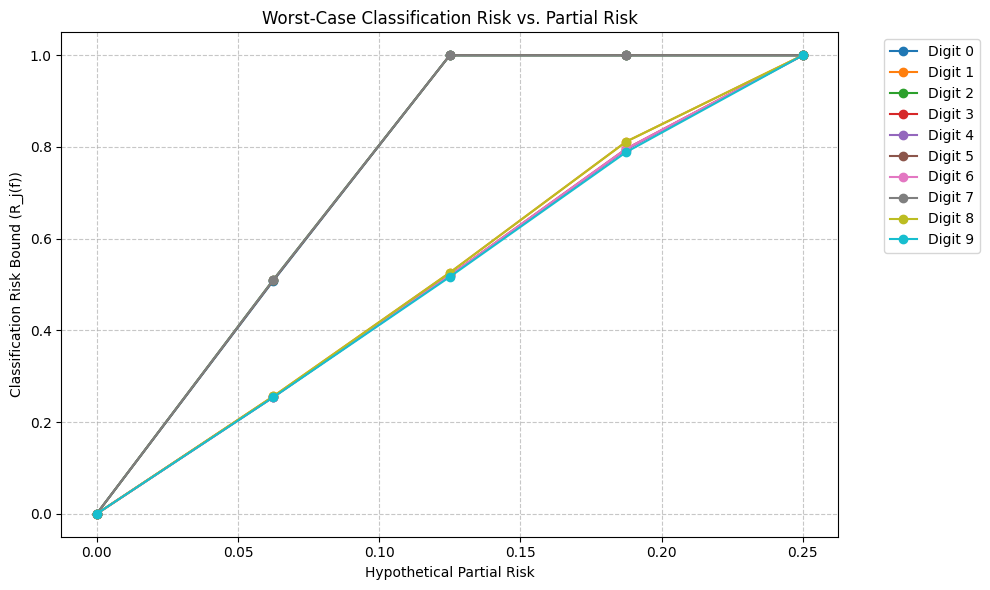

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# range of partial risks (as shown in figure 2 of the paper `Imbalances in Neurosymbolic Learning: Characterization and Mitigating Strategies`)
partial_risk_values = np.linspace(0, 0.55, 5) if args.dataset == 'halfmnist' else np.linspace(0, 0.25, 5)

# dict. to map digit -> list of risks corresponding to partial_risk_values
risk_results = {i: [] for i in range(C)}

print("Starting sweep over hypothetical partial risks...")

for pr in partial_risk_values:
    print(f"Processing Partial Risk: {pr:.2f}")
    for target_class in range(C):
        # solve the optimization problem for the current class and partial risk
        risk_bound = compute_class_specific_risk_bound(
            target_class, 
            pr, 
            C, 
            Sigma
        )
        
        if risk_bound is None:
            risk_results[target_class].append(np.nan)
        else:
            risk_results[target_class].append(risk_bound)

plt.figure(figsize=(10, 6))

# use a colormap to ensure distinct colors for each digit
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for target_class in range(C):
    plt.plot(
        partial_risk_values, 
        risk_results[target_class], 
        marker='o', 
        label=f'Digit {target_class}',
        color=colors[target_class] if target_class < 10 else None
    )

plt.xlabel('Hypothetical Partial Risk')
plt.ylabel('Classification Risk Bound (R_j(f))')
plt.title('Worst-Case Classification Risk vs. Partial Risk')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()